# Build a decision tree classifier to predict wheather a customer will purchase a product or service based on their demographic and behavioral data.Use a dataset such as the bank marketing dataset from the UCI Machine Learning Repository.

In [1]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('datasets/bank-full.csv', sep=';')
print(f"Dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Target distribution:\n{df['y'].value_counts()}")
print(f"Purchase rate: {(df['y']=='yes').mean():.1%}")

Dataset: 45,211 rows × 17 columns
Target distribution:
y
no     39922
yes     5289
Name: count, dtype: int64
Purchase rate: 11.7%


In [3]:
le = LabelEncoder()
cat_cols = ['job','marital','education','default','housing','loan',
            'contact','month','poutcome']
df_enc = df.copy()
for col in cat_cols:
    df_enc[col] = le.fit_transform(df_enc[col])
df_enc['y'] = (df_enc['y'] == 'yes').astype(int)
 
X = df_enc.drop('y', axis=1)
y_target = df_enc['y']
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y_target, test_size=0.2, random_state=42, stratify=y_target)

In [4]:
dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=50,
    min_samples_leaf=20,
    random_state=42,
    class_weight='balanced'   # handles class imbalance (88% no, 12% yes)
)
dt.fit(X_train, y_train)
 
y_pred  = dt.predict(X_test)
y_proba = dt.predict_proba(X_test)[:, 1]

In [5]:
acc       = accuracy_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_proba)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
cv_scores = cross_val_score(dt, X, y_target, cv=5, scoring='roc_auc')
 
print(f"\n{'='*55}")
print("  RESULTS")
print(f"{'='*55}")
print(f"  Accuracy        : {acc:.4f}  ({acc*100:.1f}%)")
print(f"  ROC-AUC         : {roc_auc:.4f}  ({roc_auc*100:.1f}%)")
print(f"  Precision       : {precision:.4f}  ({precision*100:.1f}%)")
print(f"  Recall          : {recall:.4f}  ({recall*100:.1f}%)")
print(f"  F1-Score        : {f1:.4f}  ({f1*100:.1f}%)")
print(f"  CV AUC (5-fold) : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print()
print(classification_report(y_test, y_pred,
      target_names=['No Purchase','Purchase'], digits=3))
 
feat_imp = pd.Series(dt.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Top Features:")
for feat, imp in feat_imp.head(8).items():
    print(f"  {feat:<15} {imp:.4f}")
 
print("\nDecision Rules (depth ≤ 3):")
print(export_text(dt, feature_names=list(X.columns), max_depth=3))


  RESULTS
  Accuracy        : 0.8000  (80.0%)
  ROC-AUC         : 0.8608  (86.1%)
  Precision       : 0.3464  (34.6%)
  Recall          : 0.8006  (80.1%)
  F1-Score        : 0.4836  (48.4%)
  CV AUC (5-fold) : 0.6409 ± 0.1330

              precision    recall  f1-score   support

 No Purchase      0.968     0.800     0.876      7985
    Purchase      0.346     0.801     0.484      1058

    accuracy                          0.800      9043
   macro avg      0.657     0.800     0.680      9043
weighted avg      0.895     0.800     0.830      9043

Top Features:
  duration        0.5605
  pdays           0.1174
  contact         0.0950
  poutcome        0.0722
  month           0.0607
  housing         0.0530
  age             0.0408
  balance         0.0004

Decision Rules (depth ≤ 3):
|--- duration <= 250.50
|   |--- pdays <= 0.00
|   |   |--- age <= 60.50
|   |   |   |--- month <= 9.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- month >  9.50
|   |   |   |   |-

Report saved.


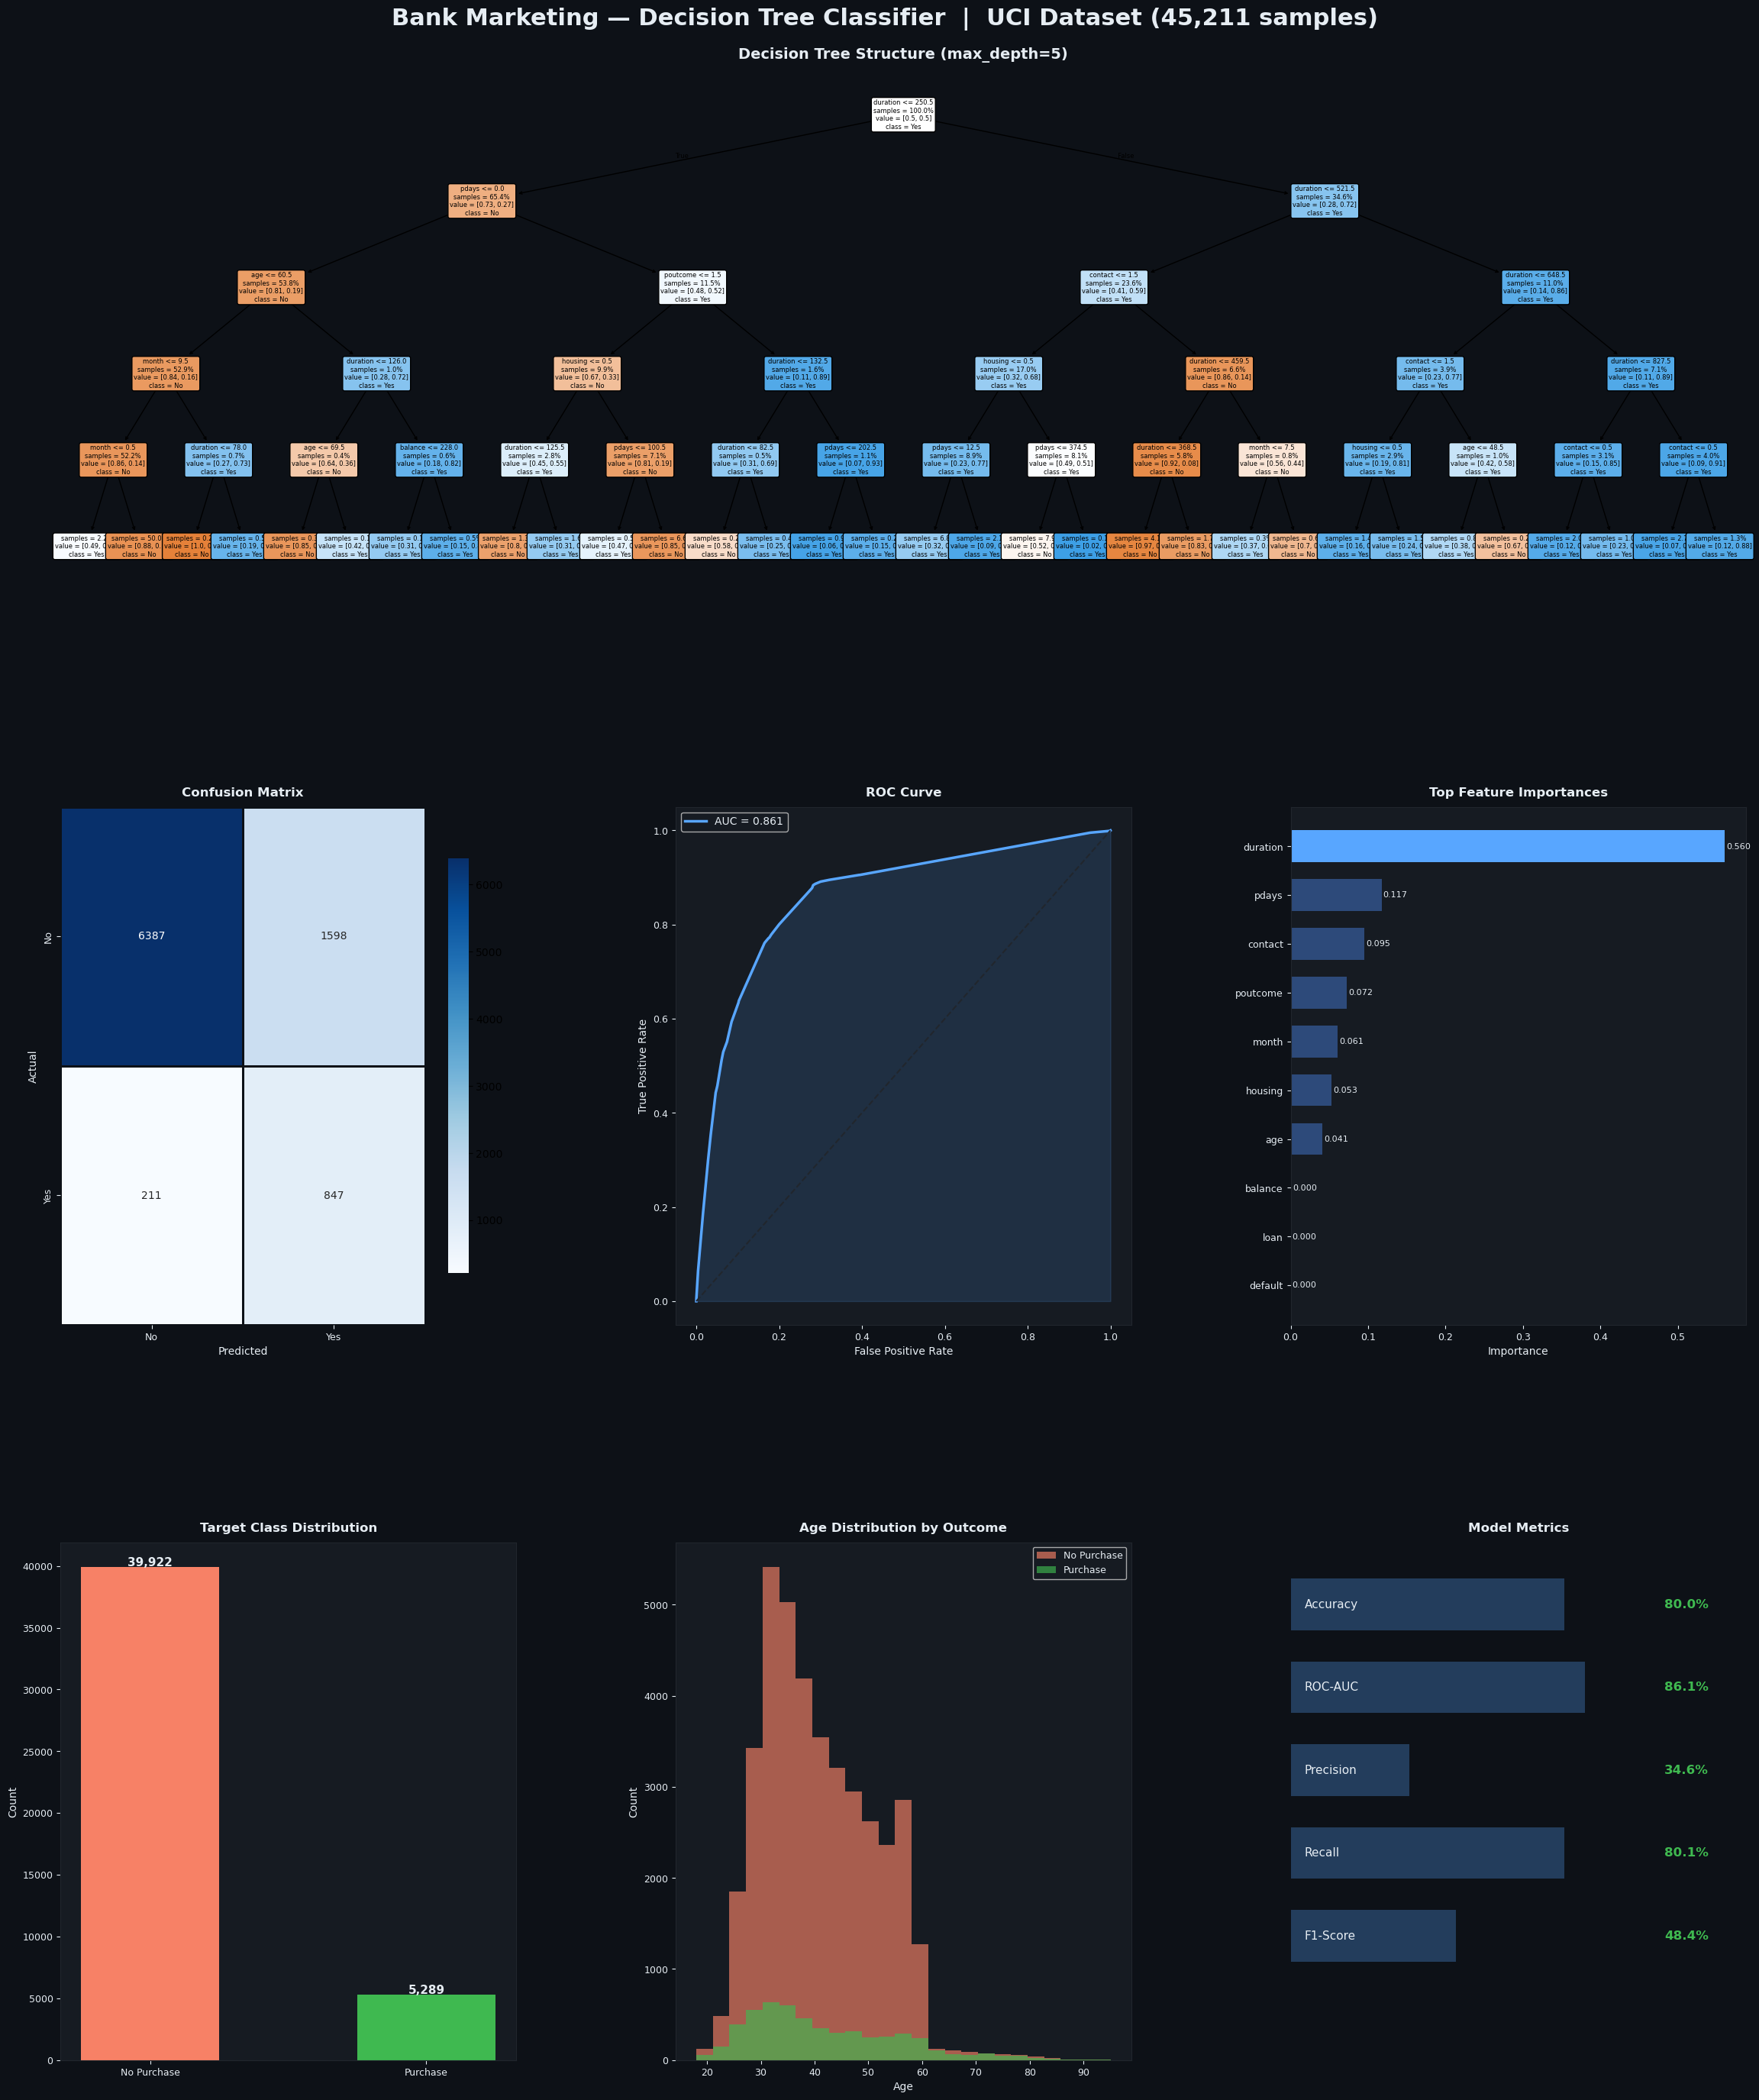

In [6]:
pal = {'bg':'#0d1117','card':'#161b22','accent':'#58a6ff','accent2':'#f78166',
       'green':'#3fb950','text':'#e6edf3','grid':'#21262d'}
 
fig = plt.figure(figsize=(24, 28), facecolor=pal['bg'])
fig.suptitle('Bank Marketing — Decision Tree Classifier  |  UCI Dataset (45,211 samples)',
             fontsize=22, color=pal['text'], fontweight='bold', y=0.99)
gs = fig.add_gridspec(3, 3, hspace=0.42, wspace=0.35,
                      left=0.05, right=0.97, top=0.96, bottom=0.03)
 
def sax(ax, title):
    ax.set_facecolor(pal['card'])
    ax.tick_params(colors=pal['text'], labelsize=9)
    for sp in ax.spines.values(): sp.set_color(pal['grid'])
    ax.set_title(title, color=pal['text'], fontsize=12, fontweight='bold', pad=10)
    for lbl in ax.get_xticklabels()+ax.get_yticklabels(): lbl.set_color(pal['text'])
 
ax_tree = fig.add_subplot(gs[0, :])
plot_tree(dt, feature_names=list(X.columns), class_names=['No','Yes'],
          filled=True, rounded=True, fontsize=6, ax=ax_tree,
          impurity=False, proportion=True, precision=2)
ax_tree.set_facecolor(pal['card'])
ax_tree.set_title('Decision Tree Structure (max_depth=5)', color=pal['text'],
                  fontsize=14, fontweight='bold', pad=12)
 
ax_cm = fig.add_subplot(gs[1, 0])
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No','Yes'], yticklabels=['No','Yes'],
            ax=ax_cm, linewidths=2, linecolor=pal['bg'], cbar_kws={'shrink':0.8})
ax_cm.set_xlabel('Predicted', color=pal['text']); ax_cm.set_ylabel('Actual', color=pal['text'])
sax(ax_cm, 'Confusion Matrix')
 
ax_roc = fig.add_subplot(gs[1, 1])
fpr, tpr, _ = roc_curve(y_test, y_proba)
ax_roc.plot(fpr, tpr, color=pal['accent'], lw=2.5, label=f'AUC = {roc_auc:.3f}')
ax_roc.fill_between(fpr, tpr, alpha=0.15, color=pal['accent'])
ax_roc.plot([0,1],[0,1],'--', color=pal['grid'], lw=1.5)
ax_roc.legend(facecolor=pal['card'], labelcolor=pal['text'], fontsize=10)
ax_roc.set_xlabel('False Positive Rate', color=pal['text'])
ax_roc.set_ylabel('True Positive Rate', color=pal['text'])
sax(ax_roc, 'ROC Curve')
 
ax_fi = fig.add_subplot(gs[1, 2])
top10 = feat_imp.head(10)
colors_fi = [pal['accent'] if v==top10.max() else '#2d4a7a' for v in top10.values]
bars_fi = ax_fi.barh(top10.index[::-1], top10.values[::-1],
                     color=colors_fi[::-1], edgecolor='none', height=0.65)
for bar, val in zip(bars_fi, top10.values[::-1]):
    ax_fi.text(bar.get_width()+0.002, bar.get_y()+bar.get_height()/2,
               f'{val:.3f}', va='center', color=pal['text'], fontsize=8)
ax_fi.set_xlabel('Importance', color=pal['text'])
sax(ax_fi, 'Top Feature Importances')
 
ax_dist = fig.add_subplot(gs[2, 0])
counts = df['y'].value_counts()
b2 = ax_dist.bar(['No Purchase','Purchase'], counts.values,
                 color=[pal['accent2'],pal['green']], edgecolor='none', width=0.5)
for b in b2:
    ax_dist.text(b.get_x()+b.get_width()/2, b.get_height()+100,
                 f'{b.get_height():,}', ha='center', color=pal['text'],
                 fontsize=11, fontweight='bold')
ax_dist.set_ylabel('Count', color=pal['text'])
sax(ax_dist, 'Target Class Distribution')
 
ax_age = fig.add_subplot(gs[2, 1])
for val, col, lbl in [('no',pal['accent2'],'No Purchase'),('yes',pal['green'],'Purchase')]:
    ax_age.hist(df[df['y']==val]['age'], bins=25, alpha=0.65, color=col,
                label=lbl, edgecolor='none')
ax_age.legend(facecolor=pal['card'], labelcolor=pal['text'], fontsize=9)
ax_age.set_xlabel('Age', color=pal['text']); ax_age.set_ylabel('Count', color=pal['text'])
sax(ax_age, 'Age Distribution by Outcome')
 
ax_met = fig.add_subplot(gs[2, 2])
ax_met.set_facecolor(pal['card']); ax_met.axis('off')
metrics = [('Accuracy',acc),('ROC-AUC',roc_auc),
           ('Precision',precision),('Recall',recall),('F1-Score',f1)]
y_pos = 0.88
for name, val in metrics:
    ax_met.barh([y_pos],[val*0.75], height=0.10, color=pal['accent'],
                alpha=0.30, transform=ax_met.transAxes)
    ax_met.text(0.03, y_pos, name, transform=ax_met.transAxes,
                color=pal['text'], fontsize=11, va='center')
    ax_met.text(0.82, y_pos, f'{val*100:.1f}%', transform=ax_met.transAxes,
                color=pal['green'], fontsize=12, fontweight='bold', va='center')
    y_pos -= 0.16
ax_met.set_title('Model Metrics', color=pal['text'], fontsize=12, fontweight='bold', pad=10)
 
plt.savefig('bank_dt_report.png', dpi=150, bbox_inches='tight', facecolor=pal['bg'])
print("Report saved.")